In [11]:
import pandas as pd
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 'data.csv' should be in the same directory as your script,
# or you can provide the full file path.
df = pd.read_csv("../results/all reduce benchmark - comparison.csv")

/var/folders/7b/6cz6y1310tb0rtyngbg8wd340000gn/T/ipykernel_25029/1290522520.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])  # leave room for outer legend


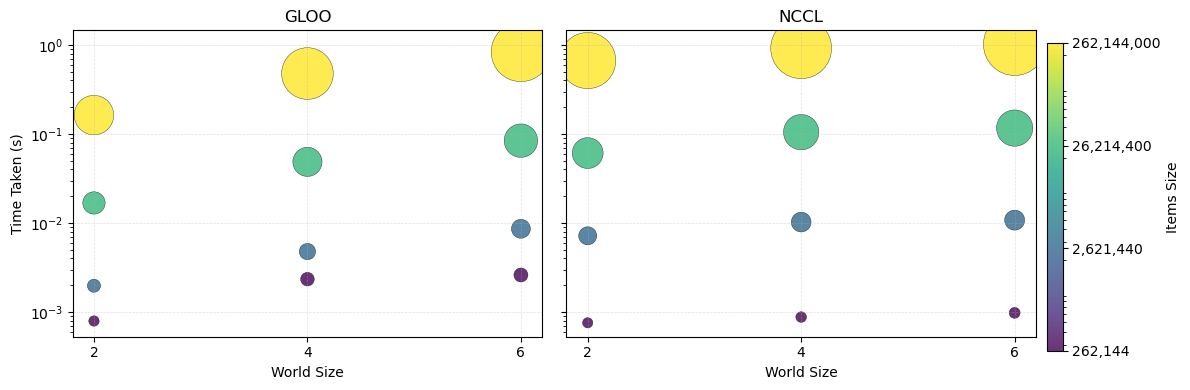

In [18]:
df["Backend"] = df["Backend"].str.upper()

# Bubble size from time (sqrt scaling usually looks good)
size_scale = 2000.0
df["bubble_s"] = size_scale * np.sqrt(df["Time Taken"])

# Shared color normalization (items size spans orders of magnitude)
norm = LogNorm(vmin=df["Items Size"].min(), vmax=df["Items Size"].max())
cmap = "viridis"

backends = ["GLOO", "NCCL"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sc_last = None
for ax, b in zip(axes, backends):
    sub = df[df["Backend"] == b].copy()

    sc = ax.scatter(
        sub["World Size"],
        sub["Time Taken"],
        s=sub["bubble_s"],
        c=sub["Items Size"],
        cmap=cmap,
        norm=norm,
        alpha=0.8,
        edgecolors="black",
        linewidths=0.3,
    )
    sc_last = sc

    ax.set_title(b)
    ax.set_xlabel("World Size")
    ax.set_xticks(sorted(df["World Size"].unique()))
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

axes[0].set_ylabel("Time Taken (s)")
for ax in axes:
    ax.set_yscale("log")
# One shared colorbar for item size
cbar = fig.colorbar(sc_last, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label("Items Size")
item_sizes = np.sort(df["Items Size"].unique())
cbar.set_ticks(item_sizes)
cbar.set_ticklabels([f"{int(x):,}" for x in item_sizes])

plt.tight_layout(rect=[0, 0, 0.88, 1])  # leave room for outer legend
plt.show()



## Inference from all reduce benchmarks
1. For smaller item size, as world size increases, the GPU communications is more optimized than GLOO.
2. For larger item size, it seems that GPU is doing more time communicating than performing the arithmetic. 